In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from gamma.artifacts import ArtifactStore
from gamma.efficiency import EfficiencyFitSpec, fit_efficiency_model, evaluate_efficiency_model
from gamma.aggregate import merge_calibrations_for_efficiency

In [2]:
store = ArtifactStore("../artifacts")

In [3]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Load Experiments
### (Load Aggregated and Subtracted Experiments from `01_ingest.ipynb`)

In [4]:
# Anil Ce
anil_ce_exp_id = "ANIL_CE_SD__agg__bkgsub"
anil_ce_exp = store.load_experiment(anil_ce_exp_id) #Loading experiment is unnecessary in this notebook

# Wenjo Ce
wenjo_ce_exp_id = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
wenjo_ce_exp = store.load_experiment(wenjo_ce_exp_id)

# Anil Ac
anil_ac_exp_id =  "ANIL_AC_SD__agg__bkgsub"
anil_ac_exp = store.load_experiment(anil_ac_exp_id)

In [5]:
anil_mix_exp_id =  "ANIL_MIX_SD__agg__bkgsub"
anil_mix_exp = store.load_experiment(anil_mix_exp_id)

anil_mix_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
anil_mix_cal =store.load_calibration(anil_mix_exp_id, anil_mix_cal_tag)

In [6]:
# anil_ce_exp_id = "ANIL_CE_SD__agg"
# anil_ce_exp = store.load_experiment(anil_ce_exp_id)

# anil_ce_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
# anil_ce_cal = store.load_calibration(anil_ce_exp.experiment_id, anil_ce_cal_tag)


# wenjo_ce_exp_id = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
# wenjo_ce_exp = store.load_experiment(wenjo_ce_exp_id)

# wenjo_ce_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
# wenjo_ce_cal = store.load_calibration(wenjo_ce_exp.experiment_id, wenjo_ce_cal_tag)

# anil_ac_exp_id = "ANIL_AC_SD__agg__bkgsub"
# anil_ac_exp =

# anil_ac_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
# anil_ac_cal =

In [7]:
# ### Just for viz I think
# anil_ce_label = next(iter(anil_ce_exp.calibrated.keys()))
# anil_ce_obj = anil_ce_exp.calibrated[anil_ce_label]
# print("schema:", anil_ce_obj.get("meta", {}).get("schema"))
# print("keys:", anil_ce_obj.keys())
# print("meta keys:", anil_ce_obj.get("meta", {}).keys())

# wenjo_ce_label = next(iter(wenjo_ce_exp.calibrated.keys()))
# wenjo_ce_obj = wenjo_ce_exp.calibrated[wenjo_ce_label]
# print("schema:", wenjo_ce_obj.get("meta", {}).get("schema"))
# print("keys:", wenjo_ce_obj.keys())
# print("meta keys:", wenjo_ce_obj.get("meta", {}).keys())

# anil_ac_label = next(iter(anil_ac_exp.calibrated.keys()))
# anil_ac_obj = anil_ac_exp.calibrated[anil_ac_label]
# print("schema:", anil_ac_obj.get("meta", {}).get("schema"))
# print("keys:", anil_ac_obj.keys())
# print("meta keys:", anil_ac_obj.get("meta", {}).keys())

# Load Calibrations
### (Load Calibrations from `02_calibrate.ipynb`)

In [8]:
anil_ce_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
anil_ce_cal = store.load_calibration(anil_ce_exp_id, anil_ce_cal_tag)

wenjo_ce_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
wenjo_ce_cal = store.load_calibration(wenjo_ce_exp_id, wenjo_ce_cal_tag)

anil_ac_cal_tag = 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'
anil_ac_cal =store.load_calibration(anil_ac_exp_id, anil_ac_cal_tag)

# Initialize Efficiency Fit Parameters

In [9]:
# Anil Ce
# This dict builds the x-axis of your response-curve fit: mapping each spectrum “label” to the known activity (in Bq)
anil_ce_label_to_activity_nCi = {lab: float(lab) for lab in anil_ce_cal.labels} 

#`EfficiencyFitSpec` is a frozen dataclass that fully specifies one fit configuration
anil_ce_fit_spec = EfficiencyFitSpec(
    name="ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1", # Recommended pattern: "{isotope}_{dataset}_resp_{emin}-{emax}keV_{rateunits}_{activityunits}_{model}_v{N}"
    label_to_activity=anil_ce_label_to_activity_nCi,
    model_type="nonparalyzable",   # or "linear"
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,        
)

# Wenjo Ce
wenjo_ce_label_to_activity_nCi = {lab: float(lab) for lab in wenjo_ce_cal.labels} 

wenjo_ce_fit_spec = EfficiencyFitSpec(
    name="ce134_wenjoSD_resp_200-1250keV_cpm_nCi_np_v1",
    label_to_activity=wenjo_ce_label_to_activity_nCi,
    model_type="nonparalyzable",   # or "linear"
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,   
)

# Anil Ac
anil_ac_label_to_activity_nCi = {lab: float(lab) for lab in anil_ac_cal.labels} 

anil_ac_fit_spec = EfficiencyFitSpec(
    name="ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1",
    label_to_activity=anil_ac_label_to_activity_nCi,
    model_type="nonparalyzable",   # or "linear"
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,   
)

# Run Fit

In [10]:
# Anil Ce
anil_ce_model = fit_efficiency_model(anil_ce_cal, anil_ce_fit_spec)
store.save_efficiency_model(anil_ce_model)

print(anil_ce_exp_id, anil_ce_model.params)

# Wenjo Ce
wenjo_ce_model = fit_efficiency_model(wenjo_ce_cal, wenjo_ce_fit_spec)
store.save_efficiency_model(wenjo_ce_model)

print(wenjo_ce_exp_id, wenjo_ce_model.params)

# Anil Ac
anil_ac_model = fit_efficiency_model(anil_ac_cal, anil_ac_fit_spec)
store.save_efficiency_model(anil_ac_model)

print(anil_ac_exp_id, anil_ac_model.params)


ANIL_CE_SD__agg__bkgsub {'a': 643.2694587750399, 'b': 9.888733240826552e-05}
WENJO_CE_SD__agg__bkgsub__nobkgrows {'a': 714.4010953108684, 'b': 0.00011396737976639658}
ANIL_AC_SD__agg__bkgsub {'a': 350.05937913017385, 'b': -2.1838106265287016e-05}


# Merge Mergeable Calibrations

In [11]:
# Merge calibration
merged_ce_cal, merged_ce_key_to_act_label = merge_calibrations_for_efficiency([anil_ce_cal, wenjo_ce_cal])

merged_ce_label_to_activity_nCi = {k: float(act_lab) for k, act_lab in merged_ce_key_to_act_label.items()}

# Initialize Merged Fit Parameters
merged_ce_spec = EfficiencyFitSpec(
    name="ce134_resp_200-1250keV_cpm_nCi_np_v1",
    label_to_activity=merged_ce_label_to_activity_nCi,
    model_type="nonparalyzable",
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,
)

# Run Merged Fit 
merged_ce_model = fit_efficiency_model(merged_ce_cal, merged_ce_spec)

# Save Merged Fit
store.save_efficiency_model(merged_ce_model)
print('Merged Ce-134 fit', merged_ce_model.params)

Merged Ce-134 fit {'a': 666.3856722953475, 'b': 0.00014065053049946288}


In [12]:
merged_ce_label_to_activity_nCi

{'ANIL_CE_SD__agg__bkgsub::1.95312': 1.95312,
 'ANIL_CE_SD__agg__bkgsub::1000': 1000.0,
 'ANIL_CE_SD__agg__bkgsub::125': 125.0,
 'ANIL_CE_SD__agg__bkgsub::15.625': 15.625,
 'ANIL_CE_SD__agg__bkgsub::250': 250.0,
 'ANIL_CE_SD__agg__bkgsub::3.90625': 3.90625,
 'ANIL_CE_SD__agg__bkgsub::31.25': 31.25,
 'ANIL_CE_SD__agg__bkgsub::500': 500.0,
 'ANIL_CE_SD__agg__bkgsub::62.5': 62.5,
 'ANIL_CE_SD__agg__bkgsub::7.8125': 7.8125,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::0.390625': 0.390625,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::0.78125': 0.78125,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::1.5625': 1.5625,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::100': 100.0,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::12.5': 12.5,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::200': 200.0,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::25': 25.0,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::3.125': 3.125,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::50': 50.0,
 'WENJO_CE_SD__agg__bkgsub__nobkgrows::6.25': 6.25}

# Visualize Activity-to-Detector-Response (Efficiency) Curves

In [13]:
def plot_efficiency_model(model, *, title=None, ax=None):
    meta = model.meta
    A = np.asarray(meta["A_used"], dtype=float)
    R = np.asarray(meta["R_used"], dtype=float)
    sigma = meta.get("R_used_sigma", None)
    sigma = None if sigma is None else np.asarray(sigma, dtype=float)

    xmin, xmax = 0.0, 1.15 * float(np.max(A))
    xgrid = np.linspace(xmin, xmax, 200)
    ygrid = evaluate_efficiency_model(model, xgrid)

    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(A, R, zorder=3, label="data")

    if sigma is not None:
        ax.errorbar(A, R, yerr=sigma, fmt="none", capsize=4, zorder=2)

    ax.plot(xgrid, ygrid, "--", zorder=1, label=f"fit ({model.model_type})")

    fit_spec = meta.get("fit_spec", {})
    units = fit_spec.get("rate_units", "counts_per_min")
    emin = fit_spec.get("emin_keV", None)
    emax = fit_spec.get("emax_keV", None)

    ax.set_xlabel("True activity (nCi)")  # change if you fit in nCi
    ax.set_ylabel(f"Integrated ROI ({units})")

    if title is None:
        title = f"{model.name}: ROI [{emin}, {emax}] keV" if (emin is not None and emax is not None) else model.name
    ax.set_title(title)

    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


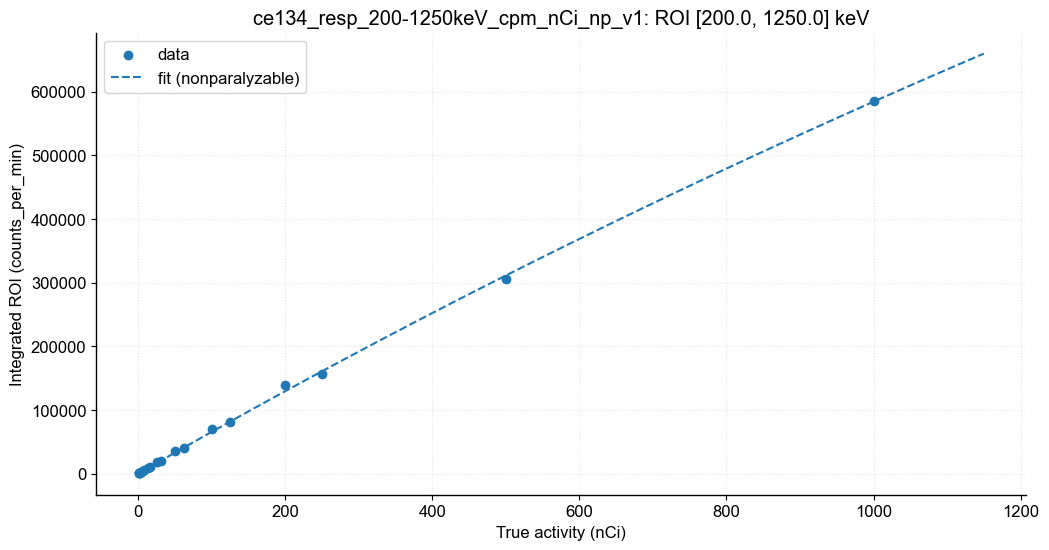

Merged Ce-134 fit {'a': 666.3856722953475, 'b': 0.00014065053049946288}


In [14]:
plot_efficiency_model(merged_ce_model)
plt.show()
print('Merged Ce-134 fit', merged_ce_model.params)


In [21]:
tot_list = [label.split('::')[1] for label in merged_ce_cal.labels]

In [23]:
label_to_activity_bq = {lab: float(lab) for lab in tot_list} 

spec = EfficiencyFitSpec(
    name="Ce134_resp_200to1250_v1",
    label_to_activity=label_to_activity_bq,
    model_type="nonparalyzable",   # or "linear"
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,               # only if not in spectrum meta
)

In [25]:
model = fit_efficiency_model(merged_ce_cal, spec)
store.save_efficiency_model(model)

model.params
# model.meta["diagnostics"]

ValueError: Not enough spectra to fit response model 'Ce134_resp_200to1250_v1'. Found 0 usable labels out of 20.

: 

In [ ]:
model

EfficiencyModel(name='Ce134_resp_200to1250_v1', model_type='nonparalyzable', params={'a': 644.0008090409527, 'b': 9.992714326456534e-05}, meta={'fit_spec': {'name': 'Ce134_resp_200to1250_v1', 'model_type': 'nonparalyzable', 'emin_keV': 200.0, 'emax_keV': 1250.0, 'livetime_s': 60.0, 'rate_units': 'counts_per_min', 'used_sigma': False}, 'used_labels': ['1.95312', '1000', '125', '15.625', '250', '3.90625', '31.25', '500', '62.5', '7.8125'], 'A_used': [1.95312, 1000.0, 125.0, 15.625, 250.0, 3.90625, 31.25, 500.0, 62.5, 7.8125], 'R_used': [1506.6666666666665, 585713.0, 81250.99999999999, 10414.333333333334, 156814.33333333334, 2827.333333333333, 20564.0, 305819.6666666667, 40519.0, 5387.0], 'R_used_sigma': None, 'diagnostics': {'nmse': 1.029652810884365e-05, 'n_points': 10, 'fit': 'scipy_curve_fit'}, 'covariance': [[6.456144258534909, 1.1894732554249227e-05], [1.1894732554249227e-05, 2.3889973780411338e-11]], 'experiment_id': 'ANIL_CE_SD__agg'})

In [ ]:
def plot_efficiency_model(model, *, title=None, ax=None):
    meta = model.meta
    A = np.asarray(meta["A_used"], dtype=float)
    R = np.asarray(meta["R_used"], dtype=float)
    sigma = meta.get("R_used_sigma", None)
    sigma = None if sigma is None else np.asarray(sigma, dtype=float)

    xmin, xmax = 0.0, 1.15 * float(np.max(A))
    xgrid = np.linspace(xmin, xmax, 200)
    ygrid = evaluate_efficiency_model(model, xgrid)

    if ax is None:
        fig, ax = plt.subplots()

    ax.scatter(A, R, zorder=3, label="data")

    if sigma is not None:
        ax.errorbar(A, R, yerr=sigma, fmt="none", capsize=4, zorder=2)

    ax.plot(xgrid, ygrid, "--", zorder=1, label=f"fit ({model.model_type})")

    fit_spec = meta.get("fit_spec", {})
    units = fit_spec.get("rate_units", "counts_per_min")
    emin = fit_spec.get("emin_keV", None)
    emax = fit_spec.get("emax_keV", None)

    ax.set_xlabel("True activity (Bq)")  # change if you fit in nCi
    ax.set_ylabel(f"Integrated ROI ({units})")

    if title is None:
        title = f"{model.name}: ROI [{emin}, {emax}] keV" if (emin is not None and emax is not None) else model.name
    ax.set_title(title)

    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


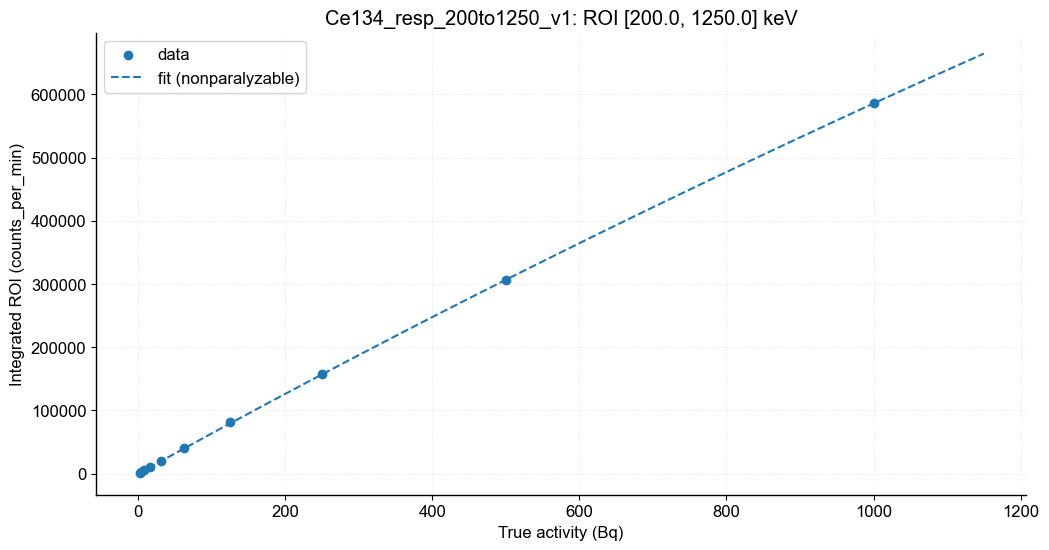

In [ ]:
plot_efficiency_model(model)
plt.show()

In [ ]:
display(model)

EfficiencyModel(name='Ce134_resp_200to1250_v1', model_type='nonparalyzable', params={'a': 644.0008090409527, 'b': 9.992714326456534e-05}, meta={'fit_spec': {'name': 'Ce134_resp_200to1250_v1', 'model_type': 'nonparalyzable', 'emin_keV': 200.0, 'emax_keV': 1250.0, 'livetime_s': 60.0, 'rate_units': 'counts_per_min', 'used_sigma': False}, 'used_labels': ['1.95312', '1000', '125', '15.625', '250', '3.90625', '31.25', '500', '62.5', '7.8125'], 'A_used': [1.95312, 1000.0, 125.0, 15.625, 250.0, 3.90625, 31.25, 500.0, 62.5, 7.8125], 'R_used': [1506.6666666666665, 585713.0, 81250.99999999999, 10414.333333333334, 156814.33333333334, 2827.333333333333, 20564.0, 305819.6666666667, 40519.0, 5387.0], 'R_used_sigma': None, 'diagnostics': {'nmse': 1.029652810884365e-05, 'n_points': 10, 'fit': 'scipy_curve_fit'}, 'covariance': [[6.456144258534909, 1.1894732554249227e-05], [1.1894732554249227e-05, 2.3889973780411338e-11]], 'experiment_id': 'ANIL_CE_SD__agg'})

In [ ]:
exp_id_2 = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
exp2 = store.load_experiment(exp_id_2)

cal_tag='peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'

cal = store.load_calibration(exp2.experiment_id, cal_tag)

In [ ]:
lab0 = next(iter(cal.calibrated.keys()))
obj0 = cal.calibrated[lab0]
print("schema:", obj0.get("meta", {}).get("schema"))
print("keys:", obj0.keys())
print("meta keys:", obj0.get("meta", {}).keys())

schema: bq_v1
keys: dict_keys(['counts_vals', 'bin_centers_kev', 'meta'])
meta keys: dict_keys(['kind', 'livetime', 'schema', 'x_attr', 'x_units', 'y_attr'])


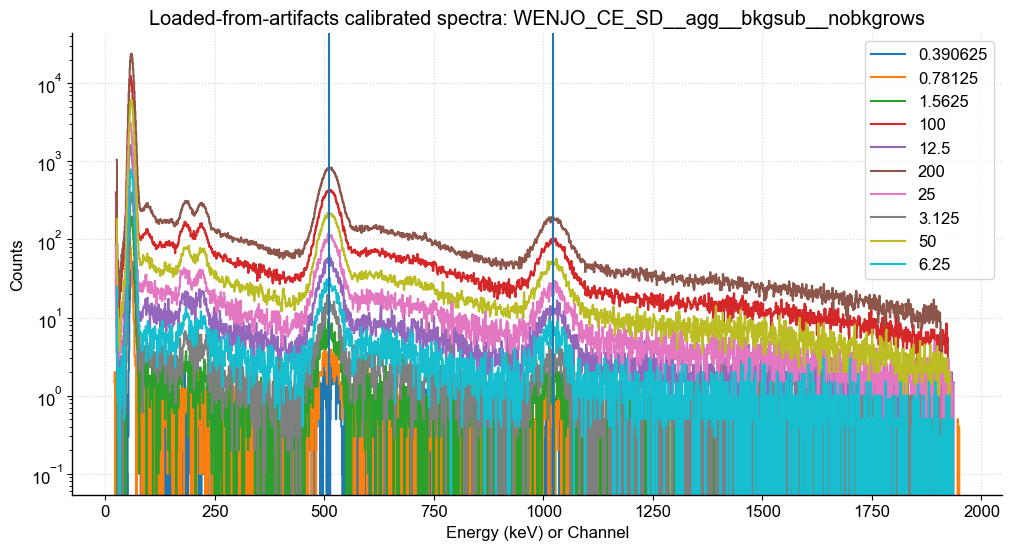

In [ ]:
# labels_to_plot = list(cal.calibrated.keys())[:]

# for lab in labels_to_plot:
#     obj = cal.calibrated[lab]
#     schema = obj.get("meta", {}).get("schema")

#     if schema != "bq_v1":
#         raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")

#     x = obj["bin_centers_kev"]
#     y = obj["counts_vals"]
#     plt.step(x, y, where="mid", label=lab)


# plt.yscale("log")
# plt.xlabel("Energy (keV) or Channel")
# plt.ylabel("Counts")
# plt.legend()
# plt.axvline(511)
# plt.axvline(1022)
# plt.title(f"Loaded-from-artifacts calibrated spectra: {cal.experiment_id}")
# plt.show()

In [ ]:
label_to_activity_bq = {lab: float(lab) for lab in cal.labels} 

spec = EfficiencyFitSpec(
    name="Ce134_resp_200to1250_v1",
    label_to_activity_bq=label_to_activity_bq,
    model_type="nonparalyzable",   # or "linear"
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,               # only if not in spectrum meta
)

In [ ]:
model2 = fit_efficiency_model(cal, spec)
store.save_efficiency_model(model2)

model2.params

{'a': 714.4010953108684, 'b': 0.00011396737976639658}

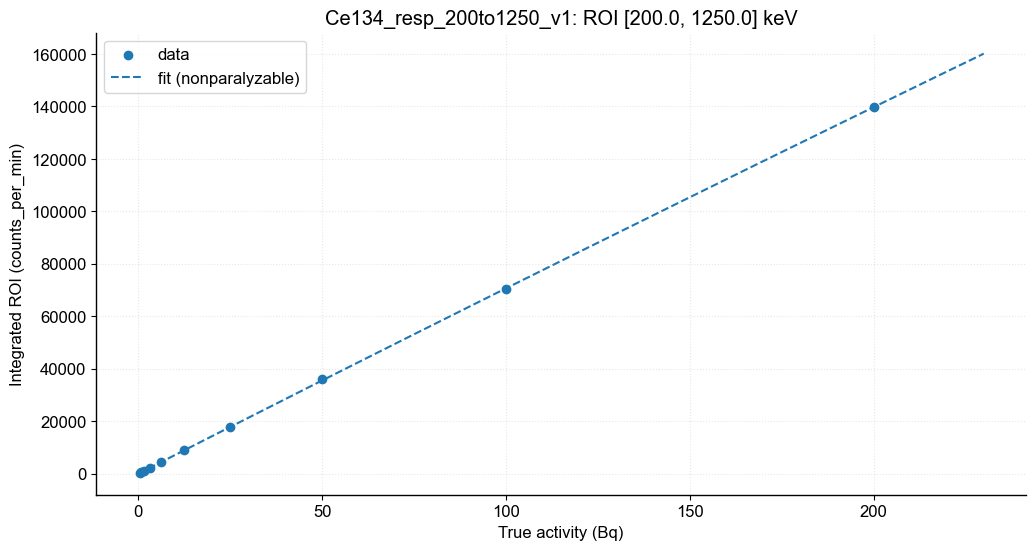

In [ ]:
plot_efficiency_model(model2)
plt.show()

In [ ]:

# load calibrations from multiple experiments/files
# cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"
# cal_a = store.load_calibration("ANIL_CE_SD__agg__bkgsub__nobkgrows", cal_tag)
# cal_b = store.load_calibration("WENJO_CE_SD__agg__bkgsub__nobkgrows", cal_tag)

merged_cal, key_to_act_label = merge_calibrations_for_efficiency([cal, cal2])

# Build mapping from merged keys to activity in Bq
# (you currently use float(label) — keep that convention)
label_to_activity_bq = {k: float(act_lab) for k, act_lab in key_to_act_label.items()}

spec = EfficiencyFitSpec(
    name="Ce134_resp_200to1250_v1",
    label_to_activity_bq=label_to_activity_bq,
    model_type="nonparalyzable",
    emin_keV=200,
    emax_keV=1250,
    livetime_s=60.0,
)

model_comb = fit_efficiency_model(merged_cal, spec)
store.save_efficiency_model(model_comb)


In [ ]:
lab0 = next(iter(merged_cal.calibrated.keys()))
obj0 = merged_cal.calibrated[lab0]
print("schema:", obj0.get("meta", {}).get("schema"))
print("keys:", obj0.keys())
print("meta keys:", obj0.get("meta", {}).keys())

schema: bq_v1
keys: dict_keys(['counts_vals', 'bin_centers_kev', 'meta'])
meta keys: dict_keys(['kind', 'livetime', 'schema', 'x_attr', 'x_units', 'y_attr'])


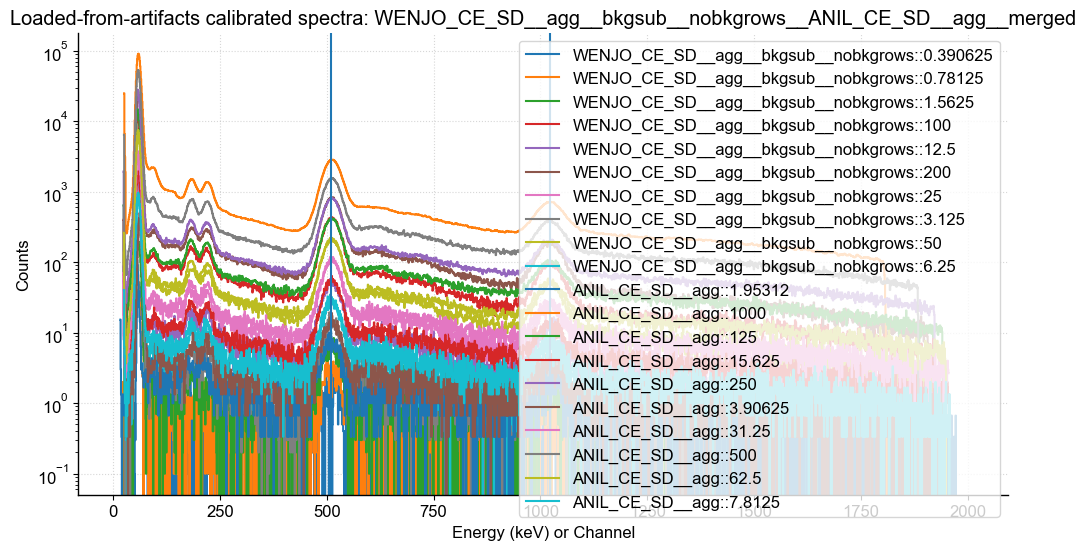

In [ ]:
# labels_to_plot = list(merged_cal.calibrated.keys())[:]

# for lab in labels_to_plot:
#     obj = merged_cal.calibrated[lab]
#     schema = obj.get("meta", {}).get("schema")

#     if schema != "bq_v1":
#         raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")

#     x = obj["bin_centers_kev"]
#     y = obj["counts_vals"]
#     plt.step(x, y, where="mid", label=lab)


# plt.yscale("log")
# plt.xlabel("Energy (keV) or Channel")
# plt.ylabel("Counts")
# plt.legend()
# plt.axvline(511)
# plt.axvline(1022)
# plt.title(f"Loaded-from-artifacts calibrated spectra: {merged_cal.experiment_id}")
# plt.show()

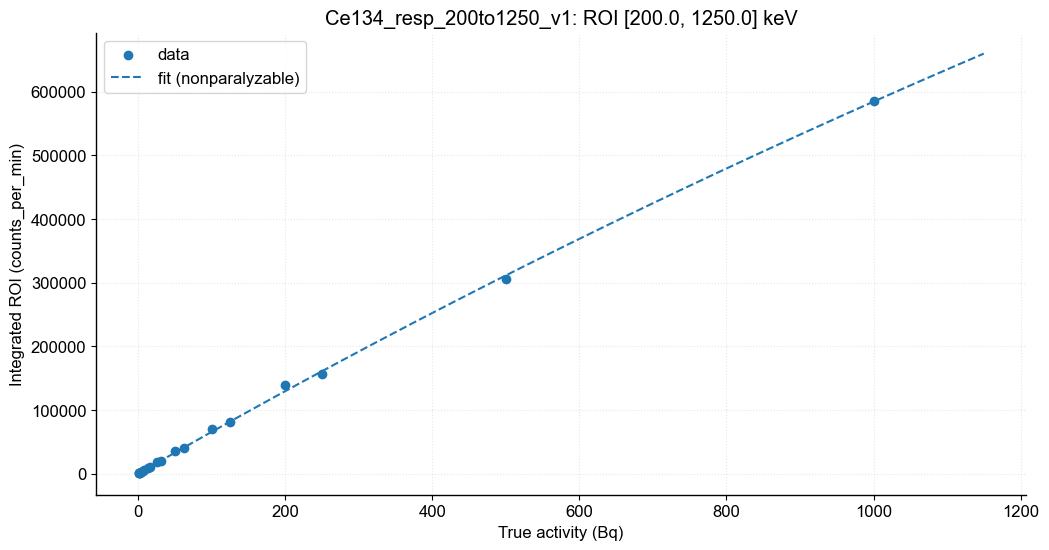

In [ ]:
plot_efficiency_model(model_comb)
plt.show()

In [ ]:
model_comb

EfficiencyModel(name='Ce134_resp_200to1250_v1', model_type='nonparalyzable', params={'a': 666.9308365575304, 'b': 0.00014134789261918462}, meta={'fit_spec': {'name': 'Ce134_resp_200to1250_v1', 'model_type': 'nonparalyzable', 'emin_keV': 200.0, 'emax_keV': 1250.0, 'livetime_s': 60.0, 'rate_units': 'counts_per_min', 'used_sigma': False}, 'used_labels': ['WENJO_CE_SD__agg__bkgsub__nobkgrows::0.390625', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::0.78125', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::1.5625', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::100', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::12.5', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::200', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::25', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::3.125', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::50', 'WENJO_CE_SD__agg__bkgsub__nobkgrows::6.25', 'ANIL_CE_SD__agg::1.95312', 'ANIL_CE_SD__agg::1000', 'ANIL_CE_SD__agg::125', 'ANIL_CE_SD__agg::15.625', 'ANIL_CE_SD__agg::250', 'ANIL_CE_SD__agg::3.90625', 'ANIL_CE_SD__agg::31.25', 'ANIL_CE_S

: 

$$R=\frac{\sum_{E\in[E_{Min}, E_{Max}]}{counts(E)}}{t_{live}}$$